# Lab 1 (simplified) · Part 2 — Inside the network
### EUROCONTROL AI Lab · Exercise 1S-2

We open the network trained in Part 1 and look at what it really is, then ask it a few *"what if…?"* questions.

| | |
|---|---|
| ⏱ **Time** | about 30 minutes |
| 🎓 **Prerequisites** | Part 1 (it saves the model). A ready-trained model is included, so this part also works on its own. |

**What you will learn**
1. A neural network is just a table of numbers (the **weights**) and a few multiplications and additions.
2. What the **activations** of the neurons are.
3. How to explain a forecast by changing one input at a time.

> **How to use this notebook**
> - Run the cells **one at a time, from top to bottom**: click a cell and press **Shift + Enter**.
> - Every line of code has a comment (the text after `#`) explaining what it does. You do not need to write any code.
> - After each plot there is a short **📖 Reading** that explains what the plot tells us.
> - If something breaks, restart and run everything again: *Kernel → Restart Kernel and Run All Cells* (JupyterLab) or *Runtime → Restart session and run all* (Colab).
> - This notebook is yours to keep: you can re-run it later and change the numbers to experiment.

> ☁️ **Running in Google Colab?** [![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/dblue-tech/ai-lab/blob/main/lab1_simplified/1S-2_inside_the_model.ipynb)  
> Run the next cell **first**: it copies the lab files (data, code, trained models) from GitHub into Colab, so that the rest of the notebook works exactly as on a PC. Wait for *"Colab ready"* (about half a minute).  
> To keep your own copy with your results: *File → Save a copy in Drive*.  
> **On a lab PC** the next cell does nothing: just run it and continue.

In [1]:
# ---- Only for Google Colab: get the lab files. On a lab PC this cell does nothing. ----
import os                                          # os: folders and files
import sys                                         # sys: information about the running Python
import subprocess                                  # subprocess: runs other programs (git, pip)

IN_COLAB = "google.colab" in sys.modules           # True when this notebook runs in Google Colab
if IN_COLAB:                                       # in Colab only:
    if not os.path.exists("/content/ai-lab"):      # if the lab files are not here yet...
        subprocess.run(["git", "clone", "--depth", "1", "https://github.com/dblue-tech/ai-lab.git", "/content/ai-lab"], check=True)   # ...copy them from GitHub
    os.chdir("/content/ai-lab/lab1_simplified")    # work inside this notebook's folder, as on a PC
    print("Colab ready — working in", os.getcwd())  # confirm
else:                                              # on a lab PC:
    print("Running on this computer: nothing to do")   # the files are already here

Running on this computer: nothing to do


---
## 0 · Setup: load the data and the saved network

In [2]:
import json                                       # json: reads and writes small text files with settings
from pathlib import Path                          # Path: file paths that work on every operating system
import numpy as np                                # numpy: calculations on arrays of numbers
import pandas as pd                               # pandas: tables of data
import matplotlib.pyplot as plt                   # matplotlib: plots
import torch                                      # PyTorch: neural networks
import torch.nn as nn                             # building blocks of neural networks

DATA_DIR = Path("../data")                        # the data folder, next to this lab's folder
ARTIFACTS = Path("artifacts")                     # where the trained model is saved

# ---- Plot style used in the whole notebook (you can skip reading this part) ----
PALETTE = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]  # 8 colours readable by colour-blind people
plt.rcParams["figure.figsize"] = (11, 4)                    # default figure size: 11 x 4 inches
plt.rcParams["axes.prop_cycle"] = plt.cycler(color=PALETTE)  # use our colours, in this order, for the lines
plt.rcParams["axes.grid"] = True                            # draw a grid behind every plot
plt.rcParams["grid.color"] = "#e6e5e0"                      # make the grid light grey
plt.rcParams["axes.spines.top"] = False                     # hide the top border of the plot
plt.rcParams["axes.spines.right"] = False                   # hide the right border of the plot
plt.rcParams["axes.titleweight"] = "bold"                   # bold titles
plt.rcParams["lines.linewidth"] = 2                         # slightly thicker lines
plt.rcParams["legend.frameon"] = False                      # no box around the legend

In [3]:
tables = []                                                      # one table per year
for year in [2023, 2024, 2025]:                                  # the three years we use
    tables.append(pd.read_csv(DATA_DIR / ("airport_traffic_" + str(year) + ".csv")))   # read the file of that year
traffic = pd.concat(tables)                                      # put the three years one after the other
traffic = traffic[traffic["APT_ICAO"] == "EBBR"]                 # keep only Brussels airport (EBBR)
traffic["FLT_DATE"] = pd.to_datetime(traffic["FLT_DATE"])        # turn the text dates into real dates
traffic = traffic.sort_values("FLT_DATE")                        # sort by date
series = pd.Series(traffic["FLT_TOT_1"].values, index=traffic["FLT_DATE"].values)   # flights per day, labelled by date

WEEKDAYS = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]   # order of the 7 weekday switches
values = series.values.astype("float32")                         # the daily traffic, as plain numbers
X_list = []                                                      # the inputs of every example
y_list = []                                                      # the answer (true traffic) of every example
dates_list = []                                                  # the date of the day to forecast
for t in range(7, len(values)):                                  # every day that has 7 days before it
    past_7_days = values[t - 7:t]                                # traffic of the 7 previous days (oldest first)
    weekday_switches = np.zeros(7, dtype="float32")              # seven switches, all off...
    weekday_switches[series.index[t].dayofweek] = 1.0            # ...switch on the weekday of the day to forecast
    X_list.append(np.concatenate([past_7_days, weekday_switches]))   # the 14 inputs of this example
    y_list.append(values[t])                                     # the answer: the traffic of day t
    dates_list.append(series.index[t])                           # the date of day t
X = np.array(X_list)                                             # all inputs: one row per example, 14 columns
y = np.array(y_list)                                             # all answers
dates = pd.DatetimeIndex(dates_list)                             # all dates

In [4]:
class TrafficNet(nn.Module):                                     # our neural network
    def __init__(self, hidden):                                  # runs when the network is created
        super().__init__()                                       # standard first line of every PyTorch model
        self.layer1 = nn.Linear(14, hidden)                      # hidden layer: 14 inputs -> `hidden` neurons
        self.output = nn.Linear(hidden, 1)                       # output layer: `hidden` neurons -> 1 number
        self.relu = nn.ReLU()                                    # keeps positive values, sets negative ones to 0

    def forward(self, x):                                        # what the network does with a batch of inputs
        h = self.relu(self.layer1(x))                            # the values (activations) of the hidden neurons
        return self.output(h).squeeze(1)                         # one number per example: the forecast (scaled)


settings = json.loads((ARTIFACTS / "traffic_net.json").read_text())   # the settings saved in Part 1
HIDDEN = settings["HIDDEN"]                                      # number of hidden neurons
MEAN = settings["MEAN"]                                          # scaling average
STD = settings["STD"]                                            # scaling spread
model = TrafficNet(HIDDEN)                                       # an empty network of the same shape...
model.load_state_dict(torch.load(ARTIFACTS / "traffic_net.pt"))  # ...filled with the learned weights
model.eval()                                                     # evaluation mode: no learning


def scale(inputs):                                               # the same scaling as in Part 1
    scaled = np.array(inputs, dtype="float32").copy()            # a copy of the 14 inputs
    scaled[:7] = (scaled[:7] - MEAN) / STD                       # scale the 7 traffic numbers
    return scaled                                                # the weekday switches stay 0/1


def forecast(inputs):                                            # the network's forecast, in flights
    with torch.no_grad():                                        # only forecasting
        return float(model(torch.tensor(scale(inputs)).unsqueeze(0))[0]) * STD + MEAN   # back to flights


print("Network loaded:", HIDDEN, "hidden neurons")               # confirm

Network loaded: 16 hidden neurons


---
## 1 · The network is a table of numbers
The hidden layer has one **weight** for every pair *(input, neuron)*, plus one **bias** per neuron. The output has one weight per neuron, plus one bias.

Hidden layer: 224 weights + 16 biases · output: 16 weights + 1 bias
Total: 257 numbers — that is the whole network


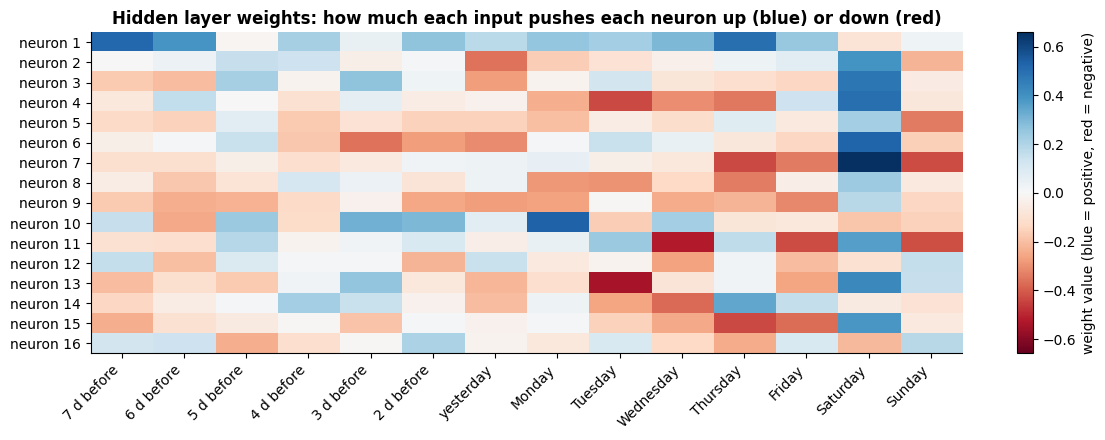

In [5]:
W1 = model.layer1.weight.detach().numpy()                        # hidden layer weights: HIDDEN rows x 14 columns
b1 = model.layer1.bias.detach().numpy()                          # hidden layer biases: one per neuron
W2 = model.output.weight.detach().numpy()                        # output weights: 1 row x HIDDEN columns
b2 = model.output.bias.detach().numpy()                          # output bias: one number
print("Hidden layer:", W1.size, "weights +", b1.size, "biases · output:", W2.size, "weights + 1 bias")   # sizes
print("Total:", W1.size + b1.size + W2.size + b2.size, "numbers — that is the whole network")   # total

input_names = ["7 d before", "6 d before", "5 d before", "4 d before", "3 d before", "2 d before", "yesterday"] + WEEKDAYS   # 14 names
limit = np.abs(W1).max()                                         # same colour scale for positive and negative weights
plt.figure(figsize=(12, 4.5))                                    # new figure
plt.imshow(W1, cmap="RdBu", vmin=-limit, vmax=limit, aspect="auto")   # one coloured square per weight
plt.grid(False)                                                  # no grid lines over the squares
plt.colorbar(label="weight value (blue = positive, red = negative)")  # the colour legend
plt.xticks(range(14), input_names, rotation=45, ha="right")      # input names on the horizontal axis
plt.yticks(range(HIDDEN), ["neuron " + str(i + 1) for i in range(HIDDEN)])   # neuron names on the vertical axis
plt.title("Hidden layer weights: how much each input pushes each neuron up (blue) or down (red)")   # title
plt.tight_layout()                                               # adjust spacing
plt.show()                                                       # display

📖 **Reading:** every square is one number learned during training. It is all there — but looking at the table does not tell us *why* the network forecasts what it does. For that we follow one forecast (§2) and ask what-if questions (§3).

---
## 2 · One forecast, by hand
We take **Saturday 13 September 2025** and repeat what the network does, with plain multiplications and additions.

> 💡 **Activation** = the number that comes out of a neuron for one particular input: *weighted sum of the inputs + bias*, then **ReLU** (negative → 0).
> It says how strongly the neuron reacts to this day. **0 = silent.** The weights are the same for every day; the activations change with every day.

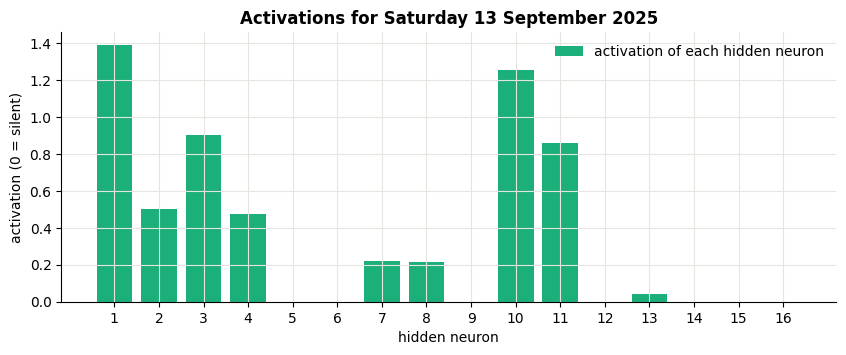

Forecast by hand : 550.0 flights
Forecast PyTorch : 550.0 flights
True traffic     : 534 flights


In [6]:
day = pd.Timestamp("2025-09-13")                                 # the day we follow
row = int(np.where(dates == day)[0][0])                          # its position among the examples
x = scale(X[row])                                                # its 14 inputs, scaled

h = np.maximum(W1 @ x + b1, 0)                                   # activations of the hidden neurons (@ = multiply by the table)
output = float((W2 @ h + b2)[0])                                 # output: weighted sum of the activations + bias
by_hand = output * STD + MEAN                                    # back to flights

plt.figure(figsize=(10, 3.5))                                    # new figure
plt.bar(range(1, HIDDEN + 1), h, color=PALETTE[2], label="activation of each hidden neuron")   # one bar per neuron
plt.xticks(range(1, HIDDEN + 1))                                 # every neuron number
plt.xlabel("hidden neuron")                                      # axis label
plt.ylabel("activation (0 = silent)")                            # axis label
plt.title("Activations for " + day.strftime("%A %d %B %Y"))      # title
plt.legend()                                                     # legend
plt.show()                                                       # display

print("Forecast by hand :", round(by_hand, 1), "flights")        # our own calculation
print("Forecast PyTorch :", round(forecast(X[row]), 1), "flights")   # the same, by the network
print("True traffic     :", int(y[row]), "flights")              # what really happened

📖 **Reading:** some neurons are silent (0), the others react with different strengths. The output adds them up with its own weights. The hand calculation gives **exactly the same forecast** as PyTorch: no magic.

---
## 3 · What if…? Explaining by changing one input
We keep the same day and change **one** thing at a time.

### 3.1 Same past week, different weekday

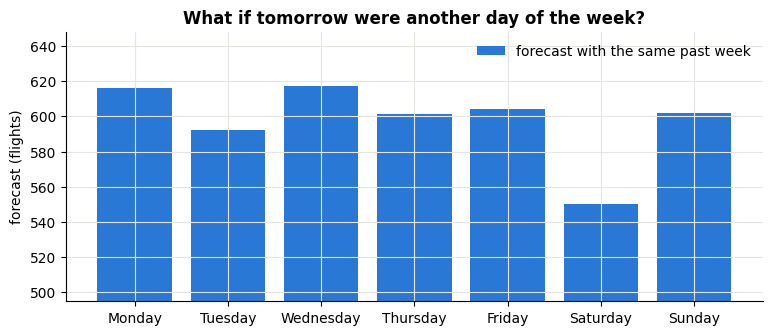

In [7]:
answers = []                                                     # the forecast for each weekday
for k in range(7):                                               # for Monday ... Sunday...
    changed = X[row].copy()                                      # ...start from the real inputs...
    changed[7:] = 0                                              # ...switch all weekdays off...
    changed[7 + k] = 1                                           # ...switch on weekday k...
    answers.append(forecast(changed))                            # ...and ask the network

plt.figure(figsize=(9, 3.5))                                     # new figure
plt.bar(WEEKDAYS, answers, color=PALETTE[0], label="forecast with the same past week")   # one bar per weekday
plt.ylim(min(answers) * 0.9, max(answers) * 1.05)                # zoom on the differences
plt.ylabel("forecast (flights)")                                 # axis label
plt.title("What if tomorrow were another day of the week?")      # title
plt.legend()                                                     # legend
plt.show()                                                       # display

📖 **Reading:** with the same past week, the forecast changes only through the weekday switch. The network has learned the **weekly rhythm**: Saturday is clearly the quietest day at Brussels.

### 3.2 What if yesterday had been very quiet or very busy?

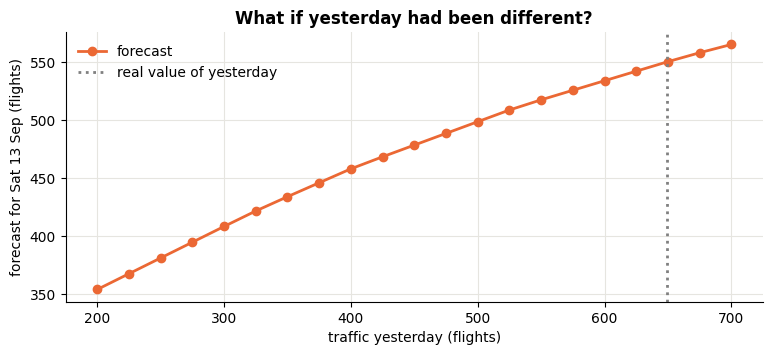

In [8]:
yesterday_values = np.arange(200, 701, 25)                       # yesterday's traffic from 200 to 700 flights
answers = []                                                     # the forecast for each value
for value in yesterday_values:                                   # for each value...
    changed = X[row].copy()                                      # ...start from the real inputs...
    changed[6] = value                                           # ...replace yesterday's traffic...
    answers.append(forecast(changed))                            # ...and ask the network

plt.figure(figsize=(9, 3.5))                                     # new figure
plt.plot(yesterday_values, answers, color=PALETTE[1], marker="o", label="forecast")   # the what-if curve
plt.axvline(X[row][6], color="grey", linestyle=":", label="real value of yesterday")  # the real value
plt.xlabel("traffic yesterday (flights)")                        # axis label
plt.ylabel("forecast for " + day.strftime("%a %d %b") + " (flights)")   # axis label
plt.title("What if yesterday had been different?")              # title
plt.legend()                                                     # legend
plt.show()                                                       # display

📖 **Reading:** a quieter yesterday pulls the forecast down: with 200 flights yesterday instead of 649, the forecast drops by about 200 flights. This is sensible for ordinary days, but after a one-day **strike** the network would wrongly expect a quiet day: it cannot know *why* yesterday was quiet.

---
## 4 · Questions for discussion
1. Which input changes the forecast more: the weekday or yesterday's traffic?
2. Would you trust this network the day after a strike? What extra information would help it?
3. Train a network with `HIDDEN = 2` in Part 1, save it, and run this notebook again. What changes?